In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import requests

In [15]:
def get_embedding(text):
    r = requests.post(
        "http://localhost:11434/api/embeddings",
        json={"model": "nomic-embed-text", "prompt": text}
    )
    return np.array(r.json()["embedding"])

In [23]:
# two similar, dis-similar or differnt texts.
t_1 = "My dog is sleeping.";
t_2 = "My dog is resting";

# result of the how similar or different those two texts are.
r_1 = get_embedding(t_1);
r_2 = get_embedding(t_2);

# result
r_1[:10], r_2[:10]


(array([-0.31136203, -0.50887632, -3.44206572,  0.33207998, -0.30195236,
         1.45425808, -1.85222423,  0.72262967, -0.34787518, -1.26458406]),
 array([ 0.35525587, -0.28268844, -4.00273418, -0.81106389,  0.16171081,
         0.85031712, -0.64127356,  1.11439478, -0.78853512, -1.79967964]))

In [16]:
def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

In [17]:
vec = get_embedding("Hello world")
print(f"Shape:      {vec.shape}")           # (768,)
print(f"Dimensions: {vec.shape[0]}")
print(f"Min:        {vec.min():.3f}")
print(f"Max:        {vec.max():.3f}")
print(f"Mean:       {vec.mean():.3f}")
print(f"Std:        {vec.std():.3f}")

Shape:      (768,)
Dimensions: 768
Min:        -3.908
Max:        2.784
Mean:       0.007
Std:        0.823


In [18]:
v1 = get_embedding("The service will not start")
v2 = get_embedding("Container keeps restarting")
v3 = get_embedding("Quarterly sales figures for the north region")

print(f"Similar:    {cosine(v1, v2):.3f}")
print(f"Unrelated:  {cosine(v1, v3):.3f}")

Similar:    0.584
Unrelated:  0.302


In [20]:
a = get_embedding("A dog is playing in the park")
b = get_embedding("A puppy is running in the garden")     # very similar
c = get_embedding("PostgreSQL is a relational database")  # unrelated

print(f"Very similar: {cosine(a, b):.3f}")   # expect ~0.6+
print(f"Unrelated:    {cosine(a, c):.3f}")   # expect ~0.1–0.2

Very similar: 0.698
Unrelated:    0.391


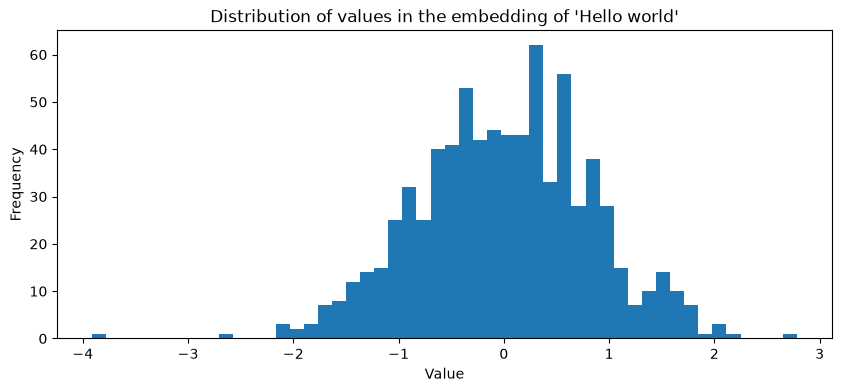

In [19]:
plt.figure(figsize=(10, 4))
plt.hist(vec, bins=50)
plt.title("Distribution of values in the embedding of 'Hello world'")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()